In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import statsmodels.api as sm
from statsmodels.sandbox.regression.predstd import wls_prediction_std

plt.rcParams.update({'font.size': 14})

# Interpretarea coeficientilor regresiei

In [2]:
diamond = pd.read_csv('diamond.csv')
diamond.head()

,Unnamed: 0,carat,price
0,1,0.17,355
1,2,0.16,328
2,3,0.17,350
3,4,0.18,325
4,5,0.25,642


intercept: -259.62590719155486 coefficient: 3721.024851550472


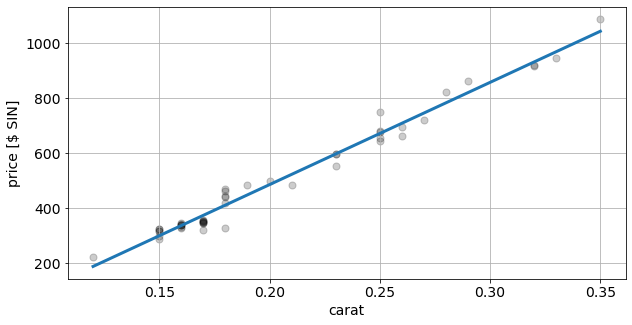

In [3]:
x, y = np.array(diamond['carat'].values), np.array(diamond['price'].values)

xext = sm.add_constant(x)

lm = sm.OLS(y, xext).fit()
beta0, beta1 = lm.params[0], lm.params[1]
print('intercept:', beta0, 'coefficient:', beta1)

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = beta0 + beta1 * x1

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y, c='k', alpha = .2, s=50)
ax.plot(x1, y1, lw=3)
ax.set(xlabel="carat", ylabel="price [$ SIN]")
ax.grid(True)
plt.show()

mean(X): 0.2041666666666667
intercept: 500.0833333333336 coefficient: 3721.024851550472


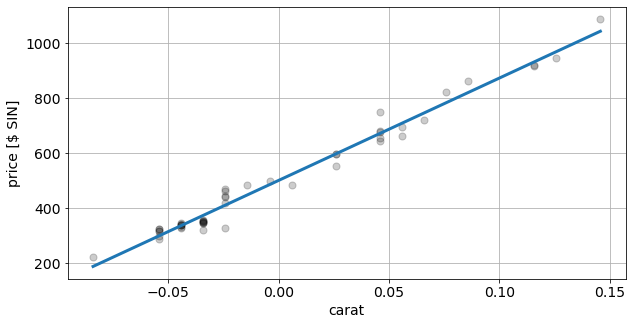

In [4]:
x, y = np.array(diamond['carat'].values), np.array(diamond['price'].values)

print('mean(X):', np.mean(x))
x -= np.mean(x)

xext = sm.add_constant(x)

lm = sm.OLS(y, xext).fit()
beta0, beta1 = lm.params[0], lm.params[1]
print('intercept:', beta0, 'coefficient:', beta1)

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = beta1 * x1 + beta0

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y, c='k', alpha = .2, s=50)
ax.plot(x1, y1, lw=3)
ax.set(xlabel="carat", ylabel="price [$ SIN]")
ax.grid(True)
plt.show()

# Residuals

intercept: -259.62590719155486 coefficient: 3721.024851550472


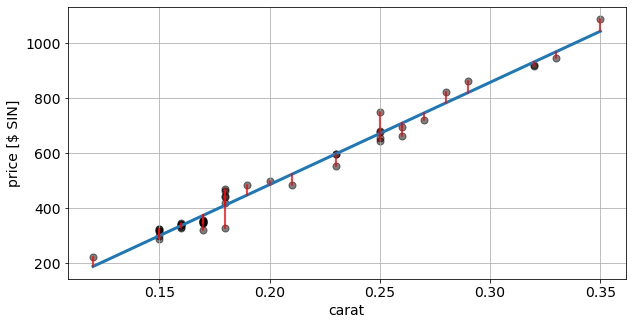

In [5]:
# diferenţa dintre y real - y de pe dreaptă

x, y = np.array(diamond['carat'].values), np.array(diamond['price'].values)

xext = sm.add_constant(x)

lm = sm.OLS(y, xext).fit()
beta0, beta1 = lm.params[0], lm.params[1]
print('intercept:', beta0, 'coefficient:', beta1)

def f(x):
    return beta0 + beta1 * x

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = f(x1)
yf = f(x)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y, c='k', alpha = .5, s=50)
ax.plot(x1, y1, lw=3)
[plt.plot([x[i], x[i]], [y[i], yf[i]], c='r') for i in range(len(x))]
ax.set(xlabel="carat", ylabel="price [$ SIN]")
ax.grid(True)
plt.show()

In [6]:
np.sum(y - yf)

1.0743406164692715e-11

In [7]:
# acestea sunt residuals, fie le luam din model, fie calculate
print(lm.resid), print(y - yf)

[-17.94831757  -7.73806906 -22.94831757 -85.15856609 -28.6303057
   6.26193094  23.47217946  37.6311854  -38.78931163  24.47217946
  51.84143391  40.73894876   0.26193094  13.42093688  -1.20980867
  40.52870024  36.10292501 -44.84055421  79.3696943  -25.05080273
  57.84143391   9.26193094 -20.94831757  -3.73806906 -19.94831757
  27.84143391 -54.94831757   8.84143391 -26.94831757  16.47217946
 -22.94831757 -13.1020453  -12.1020453   -0.52782054   3.26193094
   2.26193094  -1.20980867 -43.20980867 -27.94831757 -23.31229382
 -15.6303057   43.26720915  32.84143391   7.3696943    4.3696943
 -11.52782054 -14.84055421  17.47217946]
[-17.94831757  -7.73806906 -22.94831757 -85.15856609 -28.6303057
   6.26193094  23.47217946  37.6311854  -38.78931163  24.47217946
  51.84143391  40.73894876   0.26193094  13.42093688  -1.20980867
  40.52870024  36.10292501 -44.84055421  79.3696943  -25.05080273
  57.84143391   9.26193094 -20.94831757  -3.73806906 -19.94831757
  27.84143391 -54.94831757   8.8414339

(None, None)

In [8]:
# tehnic, suma reziduurilor este zero
np.sum(lm.resid), np.sum(lm.resid * x)

(1.0743406164692715e-11, 2.3447910280083306e-12)

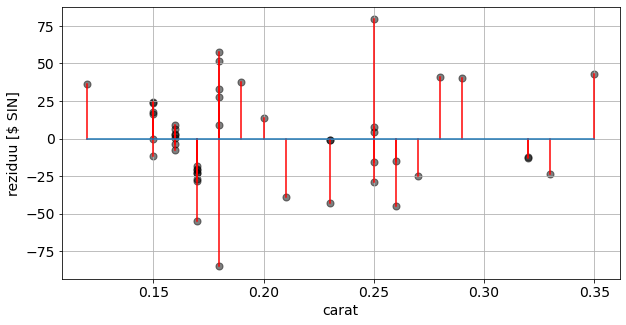

In [9]:
# scatter plot pentru residuals
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, lm.resid, c='k', alpha = .5, s=50)
[plt.plot([x[i], x[i]], [0, lm.resid[i]], c='r') for i in range(len(x))]
plt.plot([np.min(x), np.max(x)], [0, 0])
ax.set(xlabel="carat", ylabel="reziduu [$ SIN]")
ax.grid(True)
plt.show()

In [10]:
# deviaţia standard a reziduurilor
print(np.sqrt(np.sum(lm.resid**2)/(len(lm.resid) - 2)))

31.840522265031762


intercept: 0.9057554394064189 coefficient: 1.3323022561559472


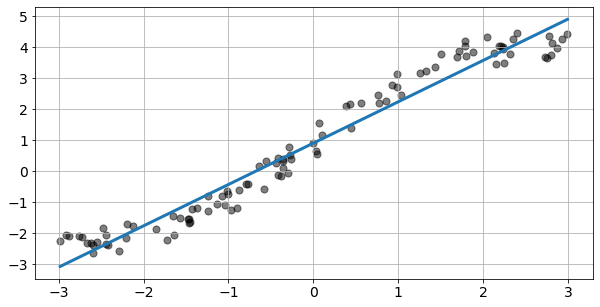

In [11]:
# model cu doua tipuri de variatii, liniara si non-liniara
x = np.random.rand(100) * 6 - 3
y = x + np.sin(x) + np.random.rand(100) + np.sqrt(0.2)

xext = sm.add_constant(x)

lm = sm.OLS(y, xext).fit()
beta0, beta1 = lm.params[0], lm.params[1]
print('intercept:', beta0, 'coefficient:', beta1)

def f(x):
    return beta0 + beta1 * x

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = f(x1)
yf = f(x)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y, c='k', alpha = .5, s=50)
ax.plot(x1, y1, lw=3)
ax.grid(True); plt.show()

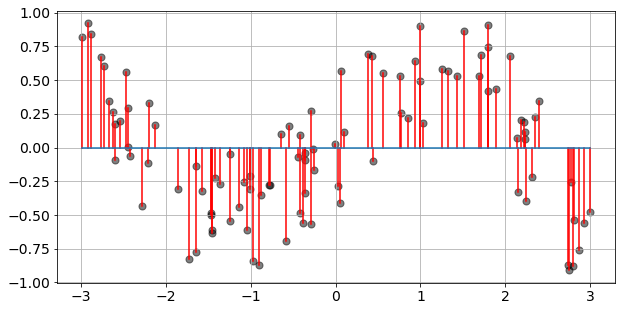

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, lm.resid, c='k', alpha = .5, s=50)
[plt.plot([x[i], x[i]], [0, lm.resid[i]], c='r') for i in range(len(x))]
plt.plot([np.min(x), np.max(x)], [0, 0])
ax.grid(True)
plt.show()

intercept: -1.5904588841347822e-05 coefficient: 0.999981501227327


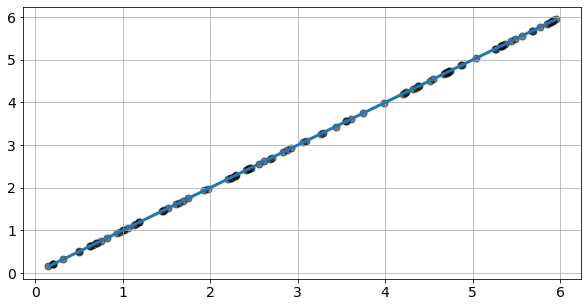

In [13]:
# model cu doua tipuri de variatii, liniara si non-liniara
x = np.random.rand(100) * 6
y = x + (np.random.rand(100) - 0.5) * .001 * x

xext = sm.add_constant(x)

lm = sm.OLS(y, xext).fit()
beta0, beta1 = lm.params[0], lm.params[1]
print('intercept:', beta0, 'coefficient:', beta1)

def f(x):
    return beta0 + beta1 * x

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = f(x1)
yf = f(x)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y, c='k', alpha = .5, s=50)
ax.plot(x1, y1, lw=3)
ax.grid(True); plt.show()

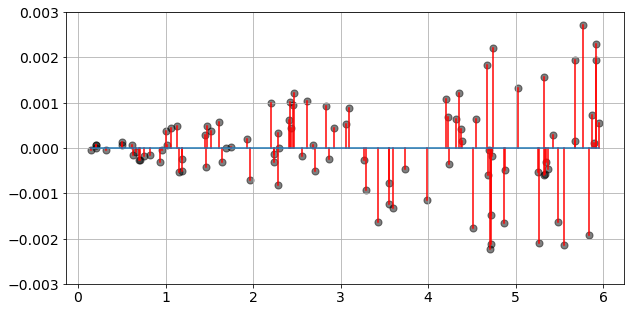

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, lm.resid, c='k', alpha = .5, s=50)
[plt.plot([x[i], x[i]], [0, lm.resid[i]], c='r') for i in range(len(x))]
plt.plot([np.min(x), np.max(x)], [0, 0])
ax.set_ylim(-0.003, 0.003)
ax.grid(True)
plt.show()

# Construcţia statisticilor pentru coeficienţii regresiei

In [15]:
# vezi documentatia, http://www.statsmodels.org/stable/examples/notebooks/generated/ols.html
x, y = np.array(diamond['carat'].values), np.array(diamond['price'].values)

xext = sm.add_constant(x)

lm = sm.OLS(y, xext).fit()
beta0, beta1 = lm.params[0], lm.params[1]
print('intercept:', beta0, 'coefficient:', beta1)

n = len(lm.resid)
sigma = np.sqrt(np.sum(lm.resid**2)/(n - 2))
print('sigma:', sigma)

sx = np.sum((x - np.mean(x))**2)
se_beta0 = np.sqrt(1/n + np.mean(x)**2 / sx) * sigma
se_beta1 = sigma / np.sqrt(sx)

stat_beta0, stat_beta1 = (beta0 - 0) / se_beta0, (beta1 - 0) / se_beta1
p_beta0 = 2 * stats.t.sf(np.abs(stat_beta0), df=n-2)
p_beta1 = 2 * stats.t.sf(np.abs(stat_beta1), df=n-2)
i_beta0 = beta0 + np.array([-1, 1]) * stats.t.ppf(0.975, df=n-2) * se_beta0
i_beta1 = beta1 + np.array([-1, 1]) * stats.t.ppf(0.975, df=n-2) * se_beta1

intercept: -259.62590719155486 coefficient: 3721.024851550472
sigma: 31.840522265031762


In [16]:
df1 = pd.DataFrame([['beta0', beta0, se_beta0, stat_beta0, p_beta0, i_beta0[0], i_beta0[1]],
                   ['beta1', beta1, se_beta1, stat_beta1, p_beta1, i_beta1[0], i_beta1[1]]],
                columns=['Parameter', 'Estimate', 'Std. Error', 't Value', 'P(>|t|)', '[0.025', '0.975]'])
df2 = pd.DataFrame([['beta0', lm.params[0], lm.bse[0], lm.tvalues[0], lm.pvalues[0], lm.conf_int()[0][0], 
                     lm.conf_int()[0][1]],
                    ['beta1', lm.params[1], lm.bse[1], lm.tvalues[1], lm.pvalues[1], lm.conf_int()[1][0], 
                     lm.conf_int()[1][1]]],                  
                columns=['Parameter', 'Estimate', 'Std. Error', 't Value', 'P(>|t|)', '[0.025', '0.975]'])
print(df1)
print(df2)

  Parameter     Estimate  Std. Error    t Value       P(>|t|)       [0.025  \
0     beta0  -259.625907   17.318856 -14.990938  2.523271e-19  -294.486957   
1     beta1  3721.024852   81.785880  45.497155  6.751260e-40  3556.398413   

        0.975]  
0  -224.764858  
1  3885.651290  
  Parameter     Estimate  Std. Error    t Value       P(>|t|)       [0.025  \
0     beta0  -259.625907   17.318856 -14.990938  2.523271e-19  -294.486957   
1     beta1  3721.024852   81.785880  45.497155  6.751260e-40  3556.398413   

        0.975]  
0  -224.764858  
1  3885.651290  


In [17]:
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     2070.
Date:                Mon, 24 Jan 2022   Prob (F-statistic):           6.75e-40
Time:                        16:32:56   Log-Likelihood:                -233.20
No. Observations:                  48   AIC:                             470.4
Df Residuals:                      46   BIC:                             474.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -259.6259     17.319    -14.991      0.0

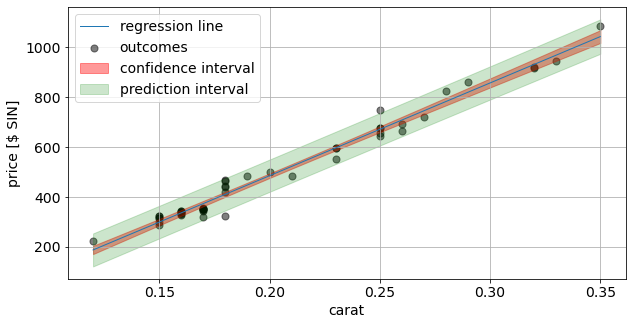

In [18]:
def f(x):
    return beta0 + beta1 * x

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = f(x1)

# t quantile
t = stats.t.ppf(0.975, df=n-2)

# dispersia reziduurilor
sigma = np.sqrt(np.sum(lm.resid**2)/(n-2))

# confidence interval pentru dreapta
ci = t * sigma * np.sqrt(1/n + (x1-np.mean(x))**2 / np.sum((x-np.mean(x))**2))

# confidence interval pentru predictie (prediction interval)
pi = t * sigma * np.sqrt(1 + 1/n + (x1-np.mean(x))**2 / np.sum((x-np.mean(x))**2))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y, c='k', alpha = .5, s=50)
ax.plot(x1, y1, lw=1)
ax.fill_between(x1, y1-ci, y1+ci, color='red', alpha=0.4)
ax.fill_between(x1, y1-pi, y1+pi, color='green', alpha=0.2)
ax.set(xlabel="carat", ylabel="price [$ SIN]")
ax.grid(True)
ax.legend(['regression line', 'outcomes', 'confidence interval', 'prediction interval'])
plt.show()

# Laborator

## Q1. Potriviți o regresie liniară pentru setul father.son cu father.height ca și predictor pentru son.height. 

In [19]:
father_son = pd.read_csv('father_son.csv')
father_son.head()

,Unnamed: 0,fheight,sheight
0,1,65.04851,59.77827
1,2,63.25094,63.21404
2,3,64.95532,63.34242
3,4,65.75250,62.79238
4,5,61.13723,64.28113


intercept: 33.88660435407803 coefficient: 0.5140930386233065


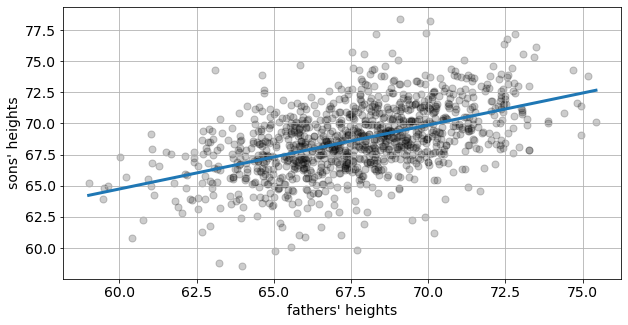

In [20]:
x, y = np.array(father_son['fheight'].values), np.array(father_son['sheight'].values)

xext = sm.add_constant(x)

lm = sm.OLS(y, xext).fit()
beta0, beta1 = lm.params[0], lm.params[1]
print('intercept:', beta0, 'coefficient:', beta1)

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = beta0 + beta1 * x1

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y, c='k', alpha = .2, s=50)
ax.plot(x1, y1, lw=3)
ax.set(xlabel="fathers' heights", ylabel="sons' heights")
ax.grid(True)
plt.show()

### a) Dați p-value pentru panta regresiei și formulați cele două ipoteze și interpretați rezultatul testului.


In [21]:
# panta: beta_1
# H0: theta=0, Ha: theta != 0 (ipoteza nulă şi alternativă), lm.summary

n = len(lm.resid)
sigma = np.sqrt(np.sum(lm.resid**2)/(n - 2))

sx = np.sum((x - np.mean(x))**2)
se_beta1 = sigma / np.sqrt(sx)

stat_beta1 = (beta1 - 0) / se_beta1
i_beta1 = beta1 + np.array([-1, 1]) * stats.t.ppf(0.975, df=n-2) * se_beta1
print(i_beta1)

[0.46101879 0.56716729]


In [22]:
print("H_0: nu există corelaţie")
print("H_a: există corelaţie")

p_beta1 = 2 * stats.t.sf(np.abs(stat_beta1), df=n-2)
print("p-value pentru panta regresiei: ", p_beta1)
print("Fiindcă p-value este foarte mic, putem rejecta ipoteza nulă, deci există corelaţie")

H_0: nu există corelaţie
H_a: există corelaţie
p-value pentru panta regresiei:  1.121267549632982e-69
Fiindcă p-value este foarte mic, putem rejecta ipoteza nulă, deci există corelaţie


### b) Interpretați de asemenea și intercept-ul.

In [23]:
# acelaşi lucru şi pentru beta0
# centrăm în zero: x-=np.mean(x)
# interpretăm intercept-ul: media înălţimii fiilor în funcţie de înălţimile taţilor

sx = np.sum((x - np.mean(x))**2)
se_beta0 = np.sqrt(1/n + np.mean(x)**2 / sx) * sigma

stat_beta0 = (beta0 - 0) / se_beta0
p_beta0 = 2 * stats.t.sf(np.abs(stat_beta0), df=n-2)
print('p_value pentru intercept: ', p_beta0)
i_beta0 = beta0 + np.array([-1, 1]) * stats.t.ppf(0.975, df=n-2) * se_beta0
print(i_beta0)

p_value pentru intercept:  1.6040440302471102e-66
[30.29121257 37.48199614]


### c) Centrați x în zero, re-aplicați regresia și interpretați intercept-ul.

intercept: 68.6840696567718 coefficient: 0.5140930386233085


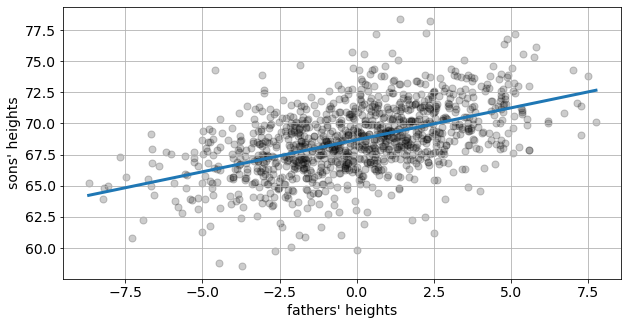

În medie, înălţimea fiului în inchi este:  68.6840696567718


In [24]:
x -= np.mean(x)

xext = sm.add_constant(x)

lm = sm.OLS(y, xext).fit()
beta0, beta1 = lm.params[0], lm.params[1]
print('intercept:', beta0, 'coefficient:', beta1)

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = beta0 + beta1 * x1

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y, c='k', alpha = .2, s=50)
ax.plot(x1, y1, lw=3)
ax.set(xlabel="fathers' heights", ylabel="sons' heights")
ax.grid(True)
plt.show()

print("În medie, înălţimea fiului în inchi este: ", beta0)

## Q2. Pentru același set father.son, preziceți înălțimea fiului dacă tatăl are înălțimea 80. Ați recomanda această predicție? Care este intervalul de confidență asociat predicției (care este intevalul de valori 95%)?

In [25]:
# x1 = 80 şi calculez y1 în x1

x, y = np.array(father_son['fheight'].values), np.array(father_son['sheight'].values)
xext = sm.add_constant(x)

lm = sm.OLS(y, xext).fit()
beta0, beta1 = lm.params[0], lm.params[1]

x1 = 80
y1 = beta0 + beta1 * x1
print("Înălţimea prezisă a fiului: ", y1)

n = len(x)
sigma = np.sqrt(np.sum(lm.resid ** 2)/(n - 2))
t = stats.t.ppf(0.975, df = n - 2)
ci = y1 + np.array([-1, 1]) * t * sigma * np.sqrt(1 + 1/n + (x1 - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
print("Intervalul de confidenţă: ", ci)

Înălţimea prezisă a fiului:  75.01404744394254
Intervalul de confidenţă:  [70.18645536 79.84163952]


## Q3. Pentru setul mtcars:

In [26]:
mtcars = pd.read_csv('mtcars.csv')
mtcars.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


### a) Realizați regresia liniară pentru mpg ca și răspuns (outcome) respectiv horsepower ca și predictor. Dați interpretarea coeficienților, recentrând x dacă e necesar. 

In [27]:
x, y = np.array(mtcars['hp'].values), np.array(mtcars['mpg'].values)
x = x - np.mean(x)
xext = sm.add_constant(x)

lm = sm.OLS(y, xext).fit()
beta0, beta1 = lm.params[0], lm.params[1]
print('intercept:', beta0, 'coefficient:', beta1)

print("În medie, mpg este: ", beta0)

intercept: 20.090625000000006 coefficient: -0.06822827807156362
În medie, mpg este:  20.090625000000006


### b) Puneți dreapta de regresie pe un scatterplot.

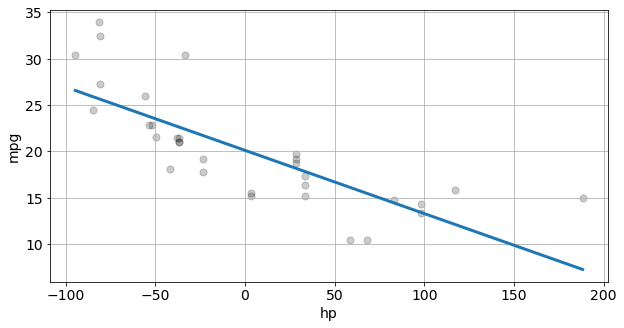

In [28]:
x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = beta0 + beta1 * x1

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y, c='k', alpha = .2, s=50)
ax.plot(x1, y1, lw=3)
ax.set(xlabel="hp", ylabel="mpg")
ax.grid(True)
plt.show()

### c) Testați ipoteza că nu există nici o corelație liniară între horsepower și mpg.

In [29]:
print("H_0: nu există corelaţie")
print("H_a: există corelaţie")

print("p-value pentru panta regresiei: ", lm.pvalues[1])
print("Fiindcă p-value este foarte mic, putem rejecta ipoteza nulă, deci există corelaţie")

H_0: nu există corelaţie
H_a: există corelaţie
p-value pentru panta regresiei:  1.7878352541210683e-07
Fiindcă p-value este foarte mic, putem rejecta ipoteza nulă, deci există corelaţie


### d) Ridicați un plot al reziduurilor vs. horsepower. Estimați dispersia reziduurilor direct, respectiv folosind modelul calculat.

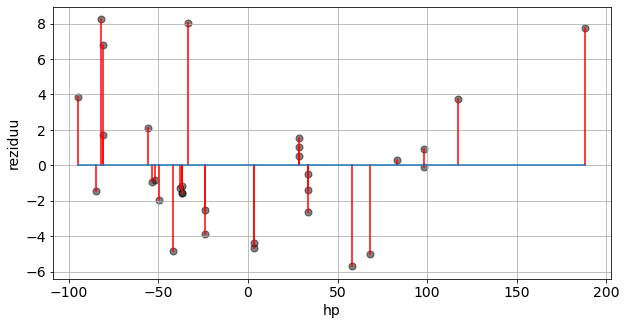

Dispersia reziduurilor:  14.92247711815339
Dispersia reziduurilor:  14.92247711815339


In [30]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, lm.resid, c='k', alpha = .5, s=50)
[plt.plot([x[i], x[i]], [0, lm.resid[i]], c='r') for i in range(len(x))]
plt.plot([np.min(x), np.max(x)], [0, 0])
ax.set(xlabel="hp", ylabel="reziduu")
ax.grid(True)
plt.show()

n = len(lm.resid)
sigma = np.sqrt(np.sum(lm.resid**2)/(n - 2))
sx = np.sum((x - np.mean(x))**2)

print('Dispersia reziduurilor: ', np.sum(lm.resid**2)/(n - 2))
print('Dispersia reziduurilor: ', lm.scale)

### e) Care este R-squared și ce exprimă el pentru acest caz?

In [31]:
# lm.summary

print(lm.rsquared)
# Cu cât R squared e mai mare, cu atât modelul de regresie se potriveste prezicerii

0.6024373414239341


## Q4. Pentru setul father.son:

In [32]:
x, y = np.array(father_son['fheight'].values), np.array(father_son['sheight'].values)

xext = sm.add_constant(x)

lm = sm.OLS(y, xext).fit()
beta0, beta1 = lm.params[0], lm.params[1]
print('intercept:', beta0, 'slope:', beta1)

intercept: 33.88660435407803 slope: 0.5140930386233065


### a) Calculați intervalul de confidență pentru intercept și pentru slope.

In [33]:
n = len(lm.resid)

sigma = np.sqrt(np.sum(lm.resid**2)/(n-2))

sx = np.sum((x - np.mean(x))**2)

se_beta0 = np.sqrt(1/n + np.mean(x)**2 / sx) * sigma
se_beta1 = sigma / np.sqrt(sx)

i_beta0 = beta0 + np.array([-1,1]) * stats.t.ppf(0.975, df = n-2) * se_beta0
i_beta1 = beta1 + np.array([-1,1]) * stats.t.ppf(0.975, df = n-2) * se_beta1

print('Interval de confidență pentru intercept: ', i_beta0)
print('Interval de confidență pentru pantă: ', i_beta1)

Interval de confidență pentru intercept:  [30.29121257 37.48199614]
Interval de confidență pentru pantă:  [0.46101879 0.56716729]


### b) Calculați intervalul de confidență pentru valoarea așteptată a înălțimii fiului pentru valoarea medie a înălțimii taților (confidence interval pentru linia de regresie, într-un punct dat).

In [34]:
x_mean = np.mean(x)
y_mean = beta0 + beta1 * x_mean

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = beta0 + beta1 * x1

t = stats.t.ppf(0.975, df = n - 2)
ci = t * sigma * np.sqrt(1/n + (x_mean - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
print("Intervalul de confidenţă pentru valoarea aşteptată a înălţimii: ", (y_mean - ci, y_mean + ci))

Intervalul de confidenţă pentru valoarea aşteptată a înălţimii:  (68.53845541171121, 68.82968390183244)


### c) Calculați prediction interval pentru înălțimea fiului pentru valoarea medie a înălțimii taților (confidence interval pentru predicție, într-un punct dat).

In [35]:
pi = t * sigma * np.sqrt(1 + 1/n + (x_mean - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
print("Prediction interval: ", (y_mean - pi, y_mean + pi))

Prediction interval:  (63.900913217204675, 73.46722609633898)


### d) Puneți pe un scatter plot punctele, dreapta de regresie și intervalele de confidență pentru valoarea așteptată respectiv predicție.

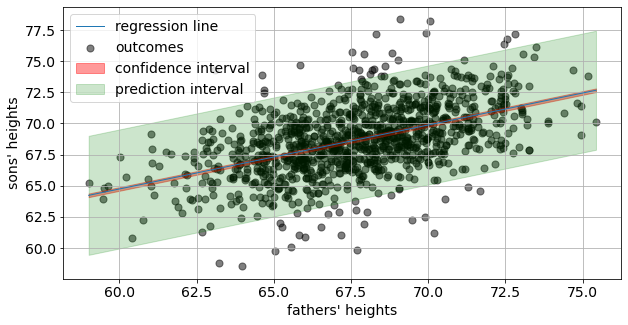

In [36]:
def f(x):
    return beta0 + beta1 * x

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = f(x1)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y, c='k', alpha = .5, s=50)
ax.plot(x1, y1, lw=1)
ax.fill_between(x1, y1-ci, y1+ci, color='red', alpha=0.4)
ax.fill_between(x1, y1-pi, y1+pi, color='green', alpha=0.2)
ax.set(xlabel="fathers' heights", ylabel="sons' heights")
ax.grid(True)
ax.legend(['regression line', 'outcomes', 'confidence interval', 'prediction interval'])
plt.show()

## Q5. Pentru setul mtcars, realizați același lucruri ca la întrebarea anterioară.

### a)

In [37]:
x, y = np.array(mtcars['hp'].values), np.array(mtcars['mpg'].values)

xext = sm.add_constant(x)

lm = sm.OLS(y, xext).fit()
beta0, beta1 = lm.params[0], lm.params[1]
print('intercept:', beta0, 'slope:', beta1)

intercept: 30.098860539622514 slope: -0.06822827807156367


### b)

In [38]:
x_mean = np.mean(x)
y_mean = beta0 + beta1 * x_mean

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = beta0 + beta1 * x1

t = stats.t.ppf(0.975, df = n - 2)
ci = t * sigma * np.sqrt(1/n + (x_mean - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
print("Intervalul de confidenţă pentru valoarea aşteptată a înălţimii: ", (y_mean - ci, y_mean + ci))

Intervalul de confidenţă pentru valoarea aşteptată a înălţimii:  (19.945010754939407, 20.236239245060627)


### c)

In [39]:
pi = t * sigma * np.sqrt(1 + 1/n + (x_mean - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
print("Prediction interval: ", (y_mean - pi, y_mean + pi))

Prediction interval:  (15.307468560432868, 24.873781439567168)


### d)

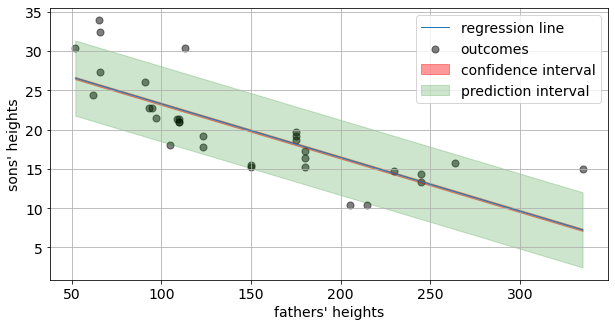

In [40]:
def f(x):
    return beta0 + beta1 * x

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = f(x1)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y, c='k', alpha = .5, s=50)
ax.plot(x1, y1, lw=1)
ax.fill_between(x1, y1-ci, y1+ci, color='red', alpha=0.4)
ax.fill_between(x1, y1-pi, y1+pi, color='green', alpha=0.2)
ax.set(xlabel="fathers' heights", ylabel="sons' heights")
ax.grid(True)
ax.legend(['regression line', 'outcomes', 'confidence interval', 'prediction interval'])
plt.show()

## Q6. Construiți două dataset-uri, y funcție de x, unul fără și altul cu variație reziduală (heteroscedasticity). x-urile vor fi comune (de exemplu, x = 1 .. 10). Mediile și dispersiile lor trebuie să fie egale. 

In [41]:
x = [i for i in range(0, 100)]
y1 = x + np.random.rand(100) - 0.5
y2 = x + (np.random.rand(100) - 0.5) * .001 * x

# Mediile şi dispersiile sunt aproximativ egale:
print("Mediile: ", (np.mean(y1), np.mean(y2)))
print("Dispersiile: ", (np.std(y1), np.std(y2)))

Mediile:  (49.51099460807966, 49.499424312819)
Dispersiile:  (28.877696005042203, 28.86517405084162)


### a) Determinați dreptele de regresie.

In [42]:
xext = sm.add_constant(x)

lm1 = sm.OLS(y1, xext).fit()
beta1_0, beta1_1 = lm1.params[0], lm1.params[1]
print('intercept:', beta1_0, 'coefficient:', beta1_1)

lm2 = sm.OLS(y2, xext).fit()
beta2_0, beta2_1 = lm2.params[0], lm2.params[1]
print('intercept:', beta2_0, 'coefficient:', beta2_1)

intercept: -0.006254011035998985 coefficient: 1.0003484569518317
intercept: 0.0009686095963452601 coefficient: 0.9999688020853064


### b) Ridicați diagrama reziduurilor.

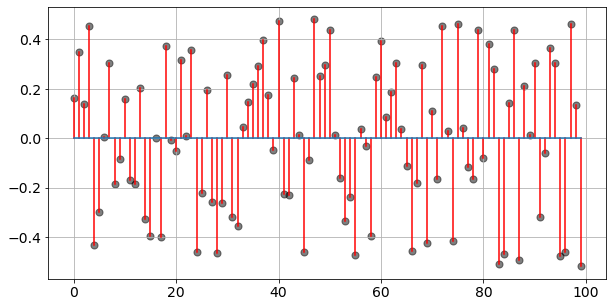

In [43]:
# diagrama reziduurilor orizontală

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, lm1.resid, c='k', alpha = .5, s=50)
[plt.plot([x[i], x[i]], [0, lm1.resid[i]], c='r') for i in range(len(x))]
plt.plot([np.min(x), np.max(x)], [0, 0])

ax.grid(True)
plt.show()

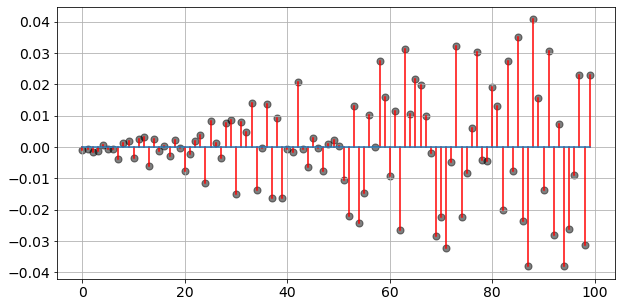

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, lm2.resid, c='k', alpha = .5, s=50)
[plt.plot([x[i], x[i]], [0, lm2.resid[i]], c='r') for i in range(len(x))]
plt.plot([np.min(x), np.max(x)], [0, 0])
ax.grid(True)
plt.show()

### c) Determinați R-squared.

In [45]:
# lm.summary

lm1.rsquared, lm2.rsquared

(0.9998914503425776, 0.9999996837496957)

### d) Afișați intevalele de confidență pentru răspunsul așteptat (dreapta de regresie) respectiv pentru predicție. Ce concluzii trageți?

In [46]:
x_mean = np.mean(x)
y_mean = beta1_0 + beta1_1 * x_mean

t = stats.t.ppf(0.975, df = n - 2)
ci = t * sigma * np.sqrt(1/n + (x_mean - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
print("Intervalul de confidenţă pentru valoarea aşteptată: ", (y_mean - ci, y_mean + ci))

pi = t * sigma * np.sqrt(1 + 1/n + (x_mean - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
print("Prediction interval: ", (y_mean - pi, y_mean + pi))

Intervalul de confidenţă pentru valoarea aşteptată:  (49.36538036301906, 49.656608853140284)
Prediction interval:  (44.72783816851252, 54.29415104764682)


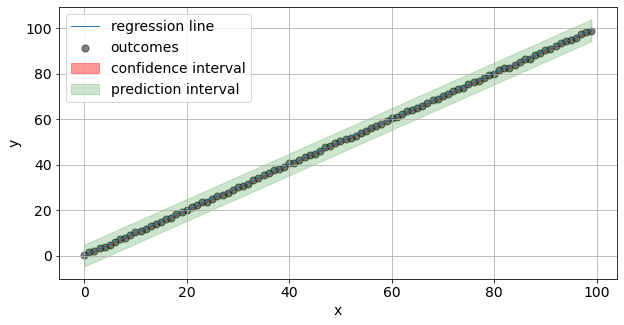

In [47]:
def f(x):
    return beta1_0 + beta1_1 * x

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y1, c='k', alpha = .5, s=50)

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = f(x1)

ax.plot(x1, y1, lw=1)
ax.fill_between(x1, y1-ci, y1+ci, color='red', alpha=0.4)
ax.fill_between(x1, y1-pi, y1+pi, color='green', alpha=0.2)
ax.set(xlabel="x", ylabel="y")
ax.grid(True)
ax.legend(['regression line', 'outcomes', 'confidence interval', 'prediction interval'])
plt.show()

In [48]:
x_mean = np.mean(x)
y_mean = beta2_0 + beta2_1 * x_mean

t = stats.t.ppf(0.975, df = n - 2)
ci = t * sigma * np.sqrt(1/n + (x_mean - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
print("Intervalul de confidenţă pentru valoarea aşteptată: ", (y_mean - ci, y_mean + ci))

pi = t * sigma * np.sqrt(1 + 1/n + (x_mean - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
print("Prediction interval: ", (y_mean - pi, y_mean + pi))

Intervalul de confidenţă pentru valoarea aşteptată:  (49.3538100677584, 49.64503855787963)
Prediction interval:  (44.716267873251866, 54.28258075238617)


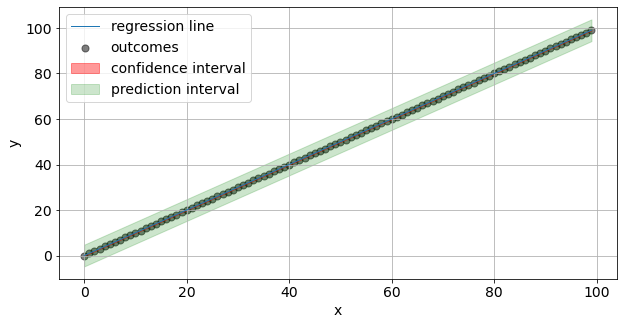

In [49]:
def f(x):
    return beta2_0 + beta2_1 * x

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y2, c='k', alpha = .5, s=50)

x1 = np.linspace(np.min(x), np.max(x), 100)
y1 = f(x1)

ax.plot(x1, y1, lw=1)
ax.fill_between(x1, y1-ci, y1+ci, color='red', alpha=0.4)
ax.fill_between(x1, y1-pi, y1+pi, color='green', alpha=0.2)
ax.set(xlabel="x", ylabel="y")
ax.grid(True)
ax.legend(['regression line', 'outcomes', 'confidence interval', 'prediction interval'])
plt.show()

In [50]:
# pt concluzii: ne uităm la p-Value

print(lm1.summary())
print(lm2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.027e+05
Date:                Mon, 24 Jan 2022   Prob (F-statistic):          4.48e-196
Time:                        16:33:00   Log-Likelihood:                -21.786
No. Observations:                 100   AIC:                             47.57
Df Residuals:                      98   BIC:                             52.78
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0063      0.060     -0.104      0.9